<br><div  class="alert alert-success" style="background-color: #045D5D; border-color: #694b98; font-size: 15pt;font-family: Serif; color: white">
        <b> <center> Introduction </center> </b>
    <a name="0"></a>
</div><br>

PySpark is the Python API for Apache Spark, an open-source big data processing framework. It provides a powerful and scalable platform for data processing and analytics. This notebook will cover the basics of PySpark and guide you through some fundamental concepts and operations.

![PySPark](https://editor.analyticsvidhya.com/uploads/374441.png)

<br><div  class="alert alert-success" style="background-color: #045D5D; border-color: #694b98; font-size: 15pt;font-family: Serif; color: white">
        <b> <center> Table of Contents </center> </b>
    <a name="0"></a>
</div><br>

### [1. Installing PySpark](#1)
### [2. Importing Required Libraries](#2)
### [3. Initializing SparkSession](#3)
### [4. Loading Data](#4)
### [5. Exploring Data](#5)
### [6. Data Transformation](#6)
### [7. Data Aggregation](#7)
### [8. Data Visualization](#8)
### [9. Writing Data](#9)
### [10. Conclusion](#10)

<br><div  class="alert alert-success" style="background-color: #045D5D; border-color: #694b98; font-size: 15pt;font-family: Serif; color: white">
        <b> <center> 1. Installing PySpark </center> </b>
    <a name="1"></a>
</div><br>

To use PySpark, you need to have Apache Spark installed on your system. You can download and install Apache Spark from the official website (https://spark.apache.org/downloads.html). Follow the installation instructions provided there.

In [22]:
!pip install pyspark

<br><div  class="alert alert-success" style="background-color: #045D5D; border-color: #694b98; font-size: 15pt;font-family: Serif; color: white">
        <b> <center> 2. Importing Required Libraries </center> </b>
    <a name="2"></a>
</div><br>

Before we start using PySpark, we need to import the necessary libraries.

In [23]:
import pyspark
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np

<br><div  class="alert alert-success" style="background-color: #045D5D; border-color: #694b98; font-size: 15pt;font-family: Serif; color: white">
        <b> <center> 3. Initializing SparkSession </center> </b>
    <a name="3"></a>
</div><br>

To interact with Spark, we need to create a SparkSession, which serves as the entry point for using PySpark.

In [25]:
spark = SparkSession.builder \
    .appName("PySpark Basics") \
    .getOrCreate()

<br><div  class="alert alert-success" style="background-color: #045D5D; border-color: #694b98; font-size: 15pt;font-family: Serif; color: white">
        <b> <center> 4. Loading Data </center> </b>
    <a name="4"></a>
</div><br>

PySpark supports various data formats, including CSV, JSON, Parquet, and more. Let's see how to load a CSV file into a PySpark DataFrame.

In [26]:
# Read a CSV file
data = spark.read.csv("/content/Stores.csv", header=True, inferSchema=True)

<br><div  class="alert alert-success" style="background-color: #045D5D; border-color: #694b98; font-size: 15pt;font-family: Serif; color: white">
        <b> <center> 5. Exploring Data </center> </b>
    <a name="5"></a>
</div><br>

Once the data is loaded into a PySpark DataFrame, we can perform various operations to explore the data.

In [6]:
# Display the first few rows of the DataFrame
data.show()

+---------+----------+---------------+--------------------+-----------+
|Store ID |Store_Area|Items_Available|Daily_Customer_Count|Store_Sales|
+---------+----------+---------------+--------------------+-----------+
|        1|      1659|           1961|                 530|      66490|
|        2|      1461|           1752|                 210|      39820|
|        3|      1340|           1609|                 720|      54010|
|        4|      1451|           1748|                 620|      53730|
|        5|      1770|           2111|                 450|      46620|
|        6|      1442|           1733|                 760|      45260|
|        7|      1542|           1858|                1030|      72240|
|        8|      1261|           1507|                1020|      37720|
|        9|      1090|           1321|                 680|      46310|
|       10|      1030|           1235|                1130|      44150|
|       11|      1187|           1439|                1090|     

### Displaying Schema

In [7]:
# Display the schema of the DataFrame
data.printSchema()

root
 |-- Store ID : integer (nullable = true)
 |-- Store_Area: integer (nullable = true)
 |-- Items_Available: integer (nullable = true)
 |-- Daily_Customer_Count: integer (nullable = true)
 |-- Store_Sales: integer (nullable = true)



### Row Counts

In [8]:
# Get the number of rows in the DataFrame
data.count()

896

### Performing Statistical Analysis

In [9]:
# Get summary statistics of numerical columns
data.describe().show()

+-------+----------------+------------------+------------------+--------------------+------------------+
|summary|       Store ID |        Store_Area|   Items_Available|Daily_Customer_Count|       Store_Sales|
+-------+----------------+------------------+------------------+--------------------+------------------+
|  count|             896|               896|               896|                 896|               896|
|   mean|           448.5|1485.4095982142858|1782.0357142857142|   786.3504464285714| 59351.30580357143|
| stddev|258.797217913949|250.23701095319237| 299.8720525241988|  265.38928076727075|17190.741894878298|
|    min|               1|               775|               932|                  10|             14920|
|    max|             896|              2229|              2667|                1560|            116320|
+-------+----------------+------------------+------------------+--------------------+------------------+



<br><div  class="alert alert-success" style="background-color: #045D5D; border-color: #694b98; font-size: 15pt;font-family: Serif; color: white">
        <b> <center> 6. Data Transformation </center> </b>
    <a name="6"></a>
</div><br>

PySpark provides a wide range of transformation operations to manipulate and preprocess data. Here are a few examples:

In [27]:
# Select specific columns
selected_data = data.select("Store ID ", "Store_Sales")

In [28]:
selected_data.show()

+---------+-----------+
|Store ID |Store_Sales|
+---------+-----------+
|        1|      66490|
|        2|      39820|
|        3|      54010|
|        4|      53730|
|        5|      46620|
|        6|      45260|
|        7|      72240|
|        8|      37720|
|        9|      46310|
|       10|      44150|
|       11|      71280|
|       12|      57620|
|       13|      60470|
|       14|      59130|
|       15|      66360|
|       16|      78870|
|       17|      77250|
|       18|      38170|
|       19|      63540|
|       20|      40190|
+---------+-----------+
only showing top 20 rows


In [29]:
# Filter rows based on a condition
filtered_data = data.filter(data["Daily_Customer_Count"] < 500)

In [31]:
filtered_data.describe().show()

+-------+------------------+------------------+------------------+--------------------+------------------+
|summary|         Store ID |        Store_Area|   Items_Available|Daily_Customer_Count|       Store_Sales|
+-------+------------------+------------------+------------------+--------------------+------------------+
|  count|               127|               127|               127|                 127|               127|
|   mean|441.66141732283467|1503.6929133858268|1803.8346456692914|   372.4409448818898|59399.291338582676|
| stddev|252.26231058331402|231.91601900260414|278.53960887239384|    98.9204950551566|16815.498103771428|
|    min|                 2|              1009|              1202|                  10|             26770|
|    max|               888|              2044|              2474|                 490|             99480|
+-------+------------------+------------------+------------------+--------------------+------------------+



In [32]:
# Add a new column
data_with_new_column = data.withColumn("Avg_Sales_per_person", data["Store_Sales"] / data["Daily_Customer_Count"])

In [33]:
data_with_new_column.show()

+---------+----------+---------------+--------------------+-----------+--------------------+
|Store ID |Store_Area|Items_Available|Daily_Customer_Count|Store_Sales|Avg_Sales_per_person|
+---------+----------+---------------+--------------------+-----------+--------------------+
|        1|      1659|           1961|                 530|      66490|  125.45283018867924|
|        2|      1461|           1752|                 210|      39820|  189.61904761904762|
|        3|      1340|           1609|                 720|      54010|   75.01388888888889|
|        4|      1451|           1748|                 620|      53730|   86.66129032258064|
|        5|      1770|           2111|                 450|      46620|               103.6|
|        6|      1442|           1733|                 760|      45260|   59.55263157894737|
|        7|      1542|           1858|                1030|      72240|   70.13592233009709|
|        8|      1261|           1507|                1020|      37720

In [34]:
data_with_new_column.describe().show()

+-------+----------------+------------------+------------------+--------------------+------------------+--------------------+
|summary|       Store ID |        Store_Area|   Items_Available|Daily_Customer_Count|       Store_Sales|Avg_Sales_per_person|
+-------+----------------+------------------+------------------+--------------------+------------------+--------------------+
|  count|             896|               896|               896|                 896|               896|                 896|
|   mean|           448.5|1485.4095982142858|1782.0357142857142|   786.3504464285714| 59351.30580357143|   94.04317457240369|
| stddev|258.797217913949|250.23701095319237| 299.8720525241988|  265.38928076727075|17190.741894878298|  162.81909882435673|
|    min|               1|               775|               932|                  10|             14920|  15.070707070707071|
|    max|             896|              2229|              2667|                1560|            116320|              

In [16]:
# Group by a column and compute aggregate functions
grouped_data = data.groupBy("Store ID ").agg({"Store_Sales": "sum"})

In [17]:
grouped_data.show()

+---------+----------------+
|Store ID |sum(Store_Sales)|
+---------+----------------+
|      148|           50360|
|      463|           43190|
|      471|           71240|
|      496|           49750|
|      833|           38510|
|      243|           69940|
|      392|           60980|
|      540|           39030|
|      623|           50730|
|      737|           59530|
|      858|           79410|
|       31|           80140|
|      516|           56440|
|       85|           90180|
|      137|           60940|
|      251|           43390|
|      451|           75880|
|      580|           79780|
|      808|           49030|
|       65|           58660|
+---------+----------------+
only showing top 20 rows


<br><div  class="alert alert-success" style="background-color: #045D5D; border-color: #694b98; font-size: 15pt;font-family: Serif; color: white">
        <b> <center> 7. Data Aggregation </center> </b>
    <a name="7"></a>
</div><br>


PySpark provides powerful functions for aggregating data. Here's an example of how to compute the average of a column:

In [35]:
# Compute the average of a column
average_value = data.selectExpr("avg((Store_Sales))").collect()[0][0]

In [36]:
average_value

59351.30580357143

8. Data Visualization

<br><div  class="alert alert-success" style="background-color: #045D5D; border-color: #694b98; font-size: 15pt;font-family: Serif; color: white">
        <b> <center> 8. Data Visualization </center> </b>
    <a name="8"></a>
</div><br>

PySpark integrates well with popular Python visualization libraries, such as Matplotlib and Seaborn. Here's an example of how to create a histogram using Matplotlib:

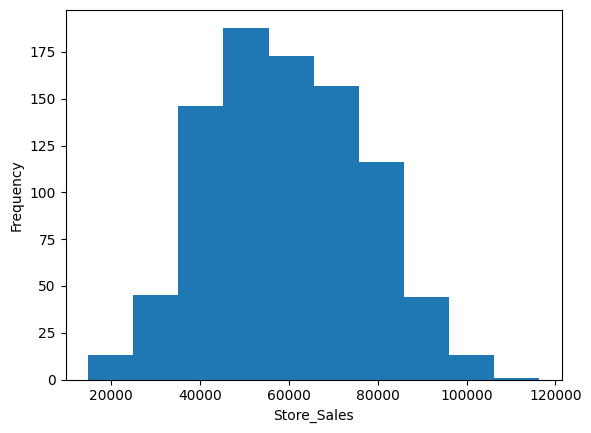

In [37]:
import matplotlib.pyplot as plt

# Convert PySpark DataFrame to Pandas DataFrame
pandas_data = data.toPandas()

# Create a histogram
plt.hist(pandas_data["Store_Sales"], bins=10)
plt.xlabel("Store_Sales")
plt.ylabel("Frequency")
plt.show()

<br><div  class="alert alert-success" style="background-color: #045D5D; border-color: #694b98; font-size: 15pt;font-family: Serif; color: white">
        <b> <center> 9. Writing Data </center> </b>
    <a name="9"></a>
</div><br>

PySpark allows us to write data back to different formats. Here's an example of how to write a PySpark DataFrame to a Parquet file:

In [38]:
# Write DataFrame to Parquet file
data.write.parquet("output.parquet")

AnalysisException: [PATH_ALREADY_EXISTS] Path file:/content/output.parquet already exists. Set mode as "overwrite" to overwrite the existing path. SQLSTATE: 42K04


<br><div  class="alert alert-success" style="background-color: #045D5D; border-color: #694b98; font-size: 15pt;font-family: Serif; color: white">
        <b> <center> 10. Conclusion </center> </b>
    <a name="10"></a>
</div><br>

This notebook provided a brief introduction to PySpark and covered some of the basics, including loading data, exploring data, data transformation, data aggregation, data visualization, and writing data.

PySpark offers many more advanced features and capabilities, which you can explore further to leverage the full power of Apache Spark for big data processing and analytics.